<a href="https://colab.research.google.com/github/natalia1126solomon/Shoreline-Hazards-and-Habitats/blob/main/eda/notebooks/EDA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
uploaded = files.upload()

Saving merged_data.csv to merged_data.csv


In [97]:
#used built-in Gemini
merged = pd.read_csv("merged_data.csv")

habitats = [
    "Forest_Present",
    "Marsh_Present",
    "Dune_Present",
    "Oyster_Reef_Present",
    "Underwater_Grass_Present"
]
hazard_mapping = {
    'Very Low': 0,
    'Low': 1,
    'Moderate': 2,
    'High': 3,
    'Very High': 4
}
hazard_order = ["Very Low", "Low", "Moderate", "High", "Very High"]
hazard_cols = [
    'Geomorphology_Hazard', 'Elevation_Hazard',
    'Sea_Level_Rise_Hazard', 'Wave_Hazard',
    'storm_surge_hazard', 'Erosion_Rate_Hazard'
]


for h in habitats:
    if h in merged.columns:

        merged.loc[:, h] = merged[h].fillna(0).astype(int)


if 'Hazard_Reduction_by_Habitats' in merged.columns:
    merged.loc[:, 'Hazard_Reduction_by_Habitats_Numeric'] = merged['Hazard_Reduction_by_Habitats'].map(hazard_mapping)
if 'Hazard_with_Habitats' in merged.columns:
    merged.loc[:, 'Hazard_with_Habitats_Numeric'] = merged['Hazard_with_Habitats'].map(hazard_mapping)
if 'Hazard_without_Habitats' in merged.columns:
    merged.loc[:, 'Hazard_without_Habitats_Numeric'] = merged['Hazard_without_Habitats'].map(hazard_mapping)


if 'Community_Flood_Risk_Max' in merged.columns:
    merged.loc[:, 'Community_Flood_Risk_Max_Numeric'] = merged['Community_Flood_Risk_Max'].map(hazard_mapping)


for col in hazard_cols:
    if col in merged.columns:
        merged.loc[:, col] = pd.Categorical(merged[col], categories=hazard_order, ordered=True)

In [98]:
results = {}

for h in habitats:

    if h in merged.columns and 'Hazard_Reduction_by_Habitats_Numeric' in merged.columns:
        results[h] = merged[merged[h] == 1]["Hazard_Reduction_by_Habitats_Numeric"].mean()

avg_reduction = pd.Series(results)
display(avg_reduction)

,0
Forest_Present,2.112970
Marsh_Present,2.129402
Dune_Present,1.966292
Oyster_Reef_Present,1.909091
Underwater_Grass_Present,2.017419


In [99]:
merged.columns

Index(['OBJECTID', 'x', 'y', 'Sheltered_Coastline', 'Geomorphology_Hazard',
       'Elevation_Hazard', 'Sea_Level_Rise_Hazard', 'Wave_Hazard',
       'storm_surge_hazard', 'Erosion_Rate_Hazard', 'Forest_Present',
       'Marsh_Present', 'Dune_Present', 'Oyster_Reef_Present',
       'Underwater_Grass_Present', 'Hazard_with_Habitats',
       'Hazard_without_Habitats', 'Hazard_Reduction_by_Habitats',
       'Community_Flood_Risk_Max', 'Community_Flood_Risk_Nearest', 'County',
       'EI_wHAB', 'EI_woHAB_x', 'hab_role', 'NearRiskD', 'Latitude',
       'Longitude', 'PercentBufferOccupied', 'HabScore',
       'PercentRemaining2100', 'PercentBufferRemain', 'PersistScore',
       'AreaScore', 'PDI', 'SVI', 'PeopleScore', 'EI_woHAB_y', 'Probability',
       'HazScore', 'TotalScore', 'Overall_Rating', 'Shape__Area',
       'Shape__Length', 'Hazard_Reduction_by_Habitats_Numeric',
       'Hazard_with_Habitats_Numeric', 'Hazard_without_Habitats_Numeric',
       'Community_Flood_Risk_Max_Numeric'],


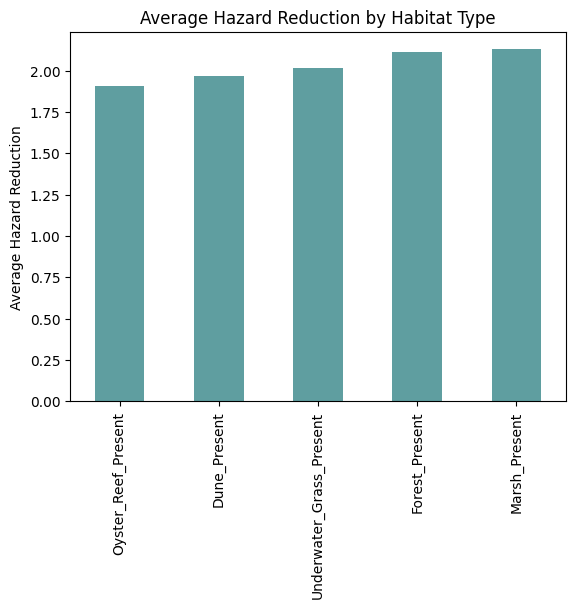

In [100]:
avg_reduction.sort_values().plot(kind="bar",color='cadetblue')
plt.ylabel("Average Hazard Reduction")
plt.title("Average Hazard Reduction by Habitat Type")
plt.show()

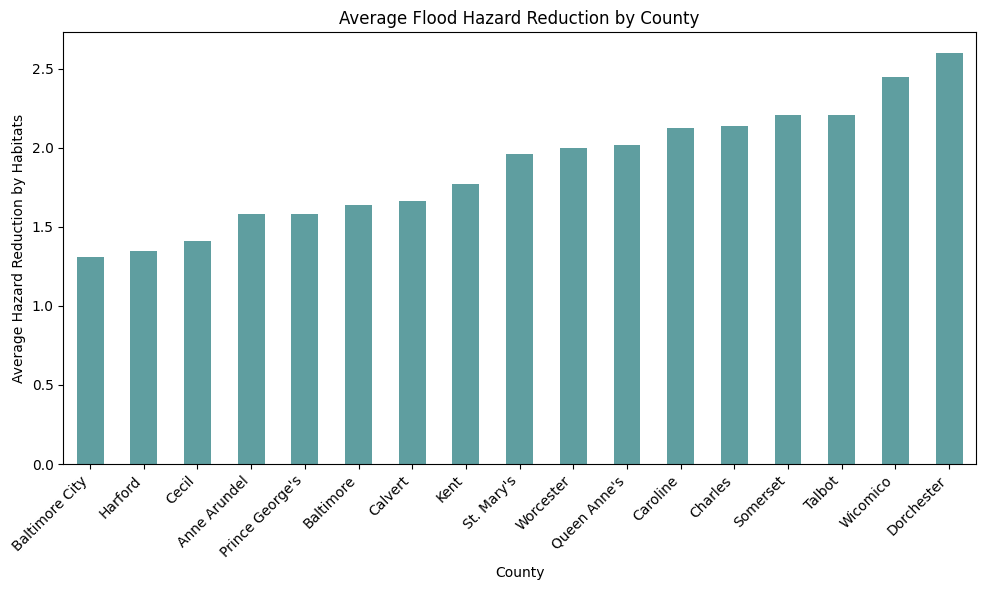

In [101]:
county_reduction = merged.groupby('County')['Hazard_Reduction_by_Habitats_Numeric'].mean()

county_reduction = county_reduction.sort_values()


plt.figure(figsize=(10, 6))
county_reduction.plot(kind='bar', color='cadetblue')

plt.xlabel('County')
plt.ylabel('Average Hazard Reduction by Habitats')
plt.title('Average Flood Hazard Reduction by County')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_535/3177405328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=county_flood_risk.index, y=county_flood_risk.values, palette='viridis')


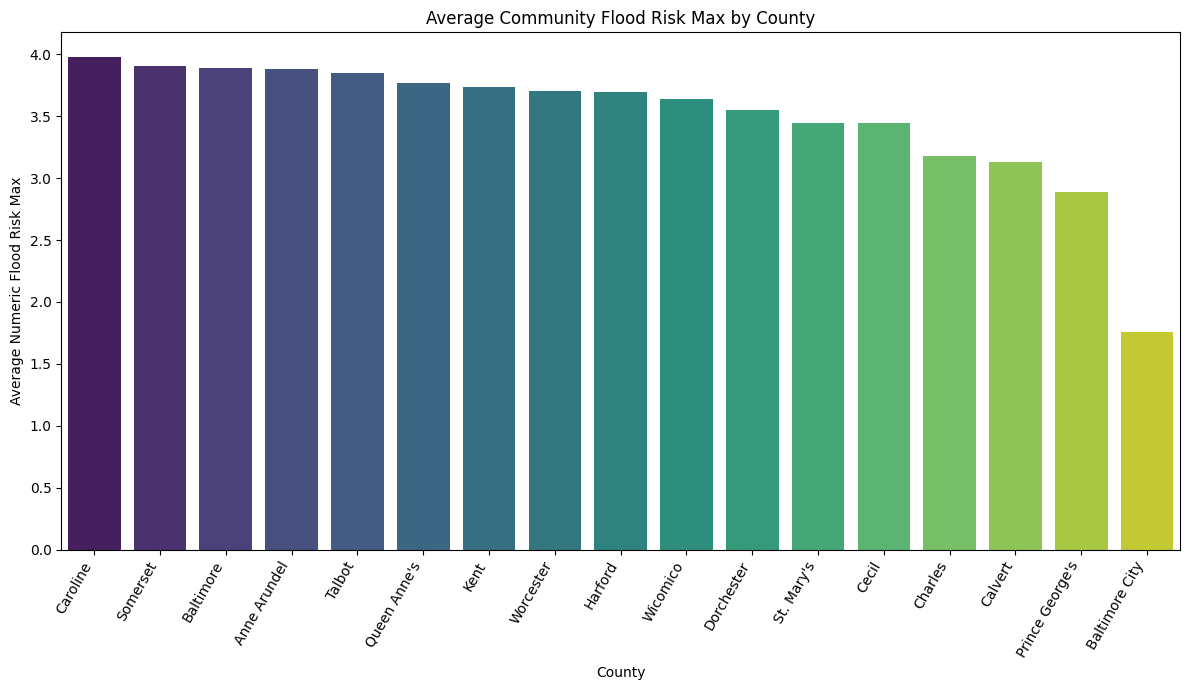

In [102]:
county_flood_risk = merged.groupby('County')['Community_Flood_Risk_Max_Numeric'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=county_flood_risk.index, y=county_flood_risk.values, palette='viridis')
plt.title('Average Community Flood Risk Max by County')
plt.xlabel('County')
plt.ylabel('Average Numeric Flood Risk Max')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

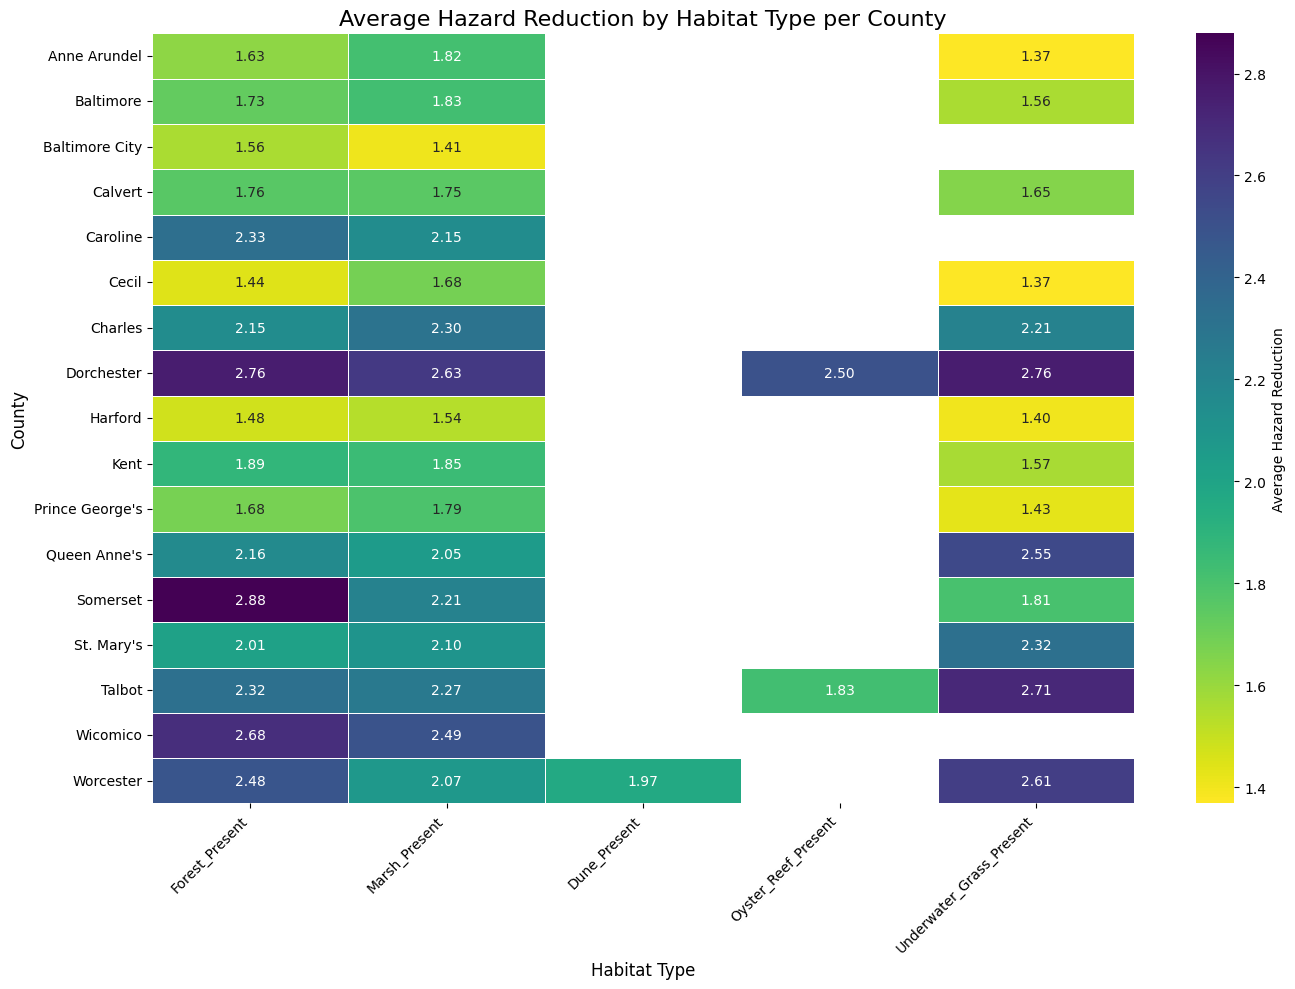

In [103]:
heatmap_data = {}

for h in habitats:

    habitat_county_reduction = merged[merged[h] == 1].groupby('County')['Hazard_Reduction_by_Habitats_Numeric'].mean()
    heatmap_data[h] = habitat_county_reduction



df_heatmap = pd.DataFrame(heatmap_data)


df_heatmap = df_heatmap.sort_index()


plt.figure(figsize=(14, 10))
sns.heatmap(df_heatmap, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Average Hazard Reduction'})

plt.title('Average Hazard Reduction by Habitat Type per County', fontsize=16)
plt.xlabel('Habitat Type', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_535/473691071.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hazard Type', y='Hazard Level Numeric', data=plot_df, palette= 'tab20')


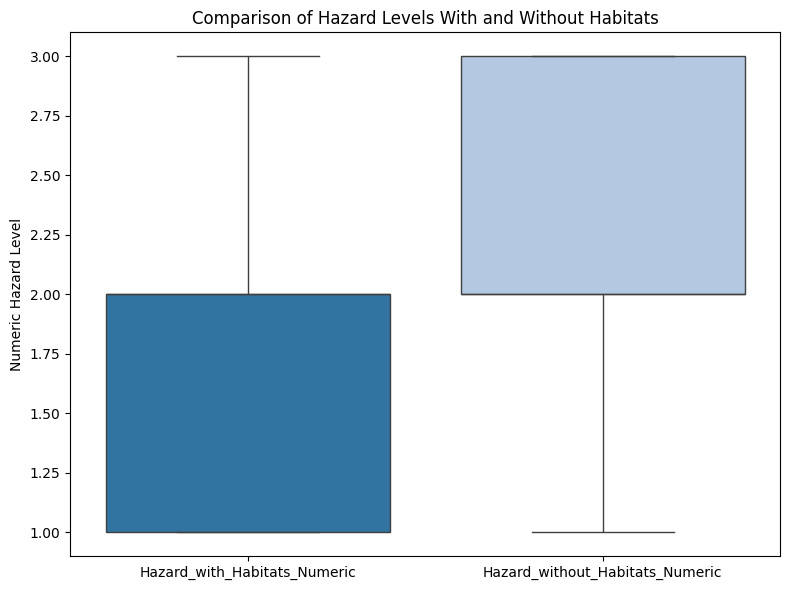

In [104]:
plot_md = merged[['Hazard_with_Habitats_Numeric', 'Hazard_without_Habitats_Numeric']].copy()
plot_md = plot_md.melt(var_name='Hazard Type', value_name='Hazard Level Numeric')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Hazard Type', y='Hazard Level Numeric', data=plot_df, palette= 'tab20')
plt.title('Comparison of Hazard Levels With and Without Habitats')
plt.ylabel('Numeric Hazard Level')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [105]:
correlation_results = {}


for h in habitats:

    temp_df = merged[[h, 'Hazard_Reduction_by_Habitats_Numeric']].dropna()


    correlation = temp_df[h].corr(temp_df['Hazard_Reduction_by_Habitats_Numeric'])
    correlation_results[h] = correlation


correlation_series = pd.Series(correlation_results)

print("Correlation between Habitat Presence and Hazard Reduction:")
print(correlation_series.sort_values(ascending=False))

Correlation between Habitat Presence and Hazard Reduction:
Forest_Present              0.386783
Marsh_Present               0.357125
Underwater_Grass_Present    0.012712
Dune_Present               -0.003234
Oyster_Reef_Present        -0.006332
dtype: float64


/tmp/ipykernel_535/231407975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_correlation.values, y=sorted_correlation.index, palette='viridis')


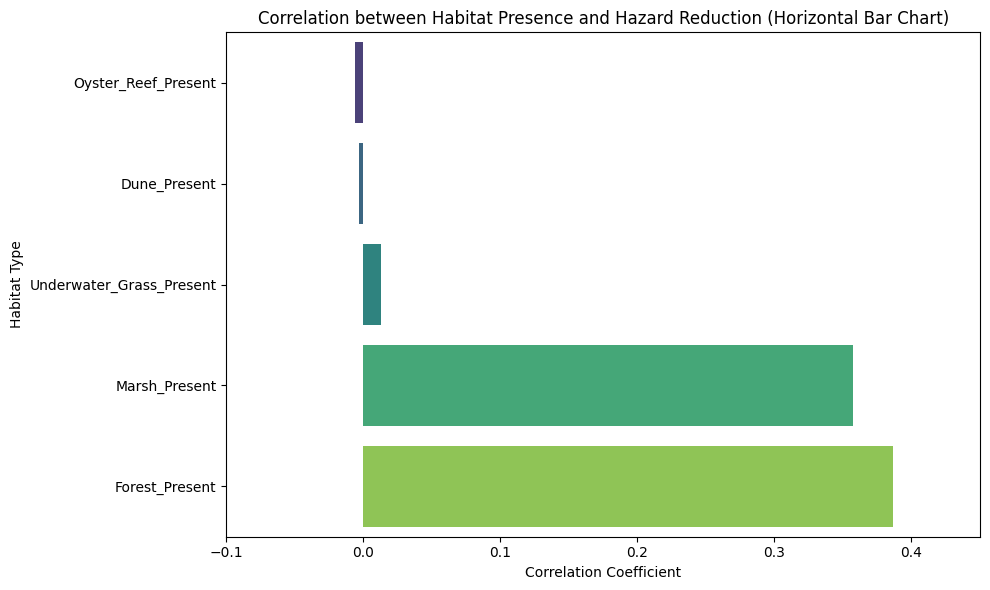

In [106]:
sorted_correlation = correlation_series.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_correlation.values, y=sorted_correlation.index, palette='viridis')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Habitat Type')
plt.title('Correlation between Habitat Presence and Hazard Reduction (Horizontal Bar Chart)')
plt.xlim(-0.1, 0.45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_535/2988577375.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_habitats_present', y='Hazard_Reduction_by_Habitats_Numeric', data=merged, palette='Blues')


Correlation between Number of Present Habitats and Hazard Reduction: 0.50


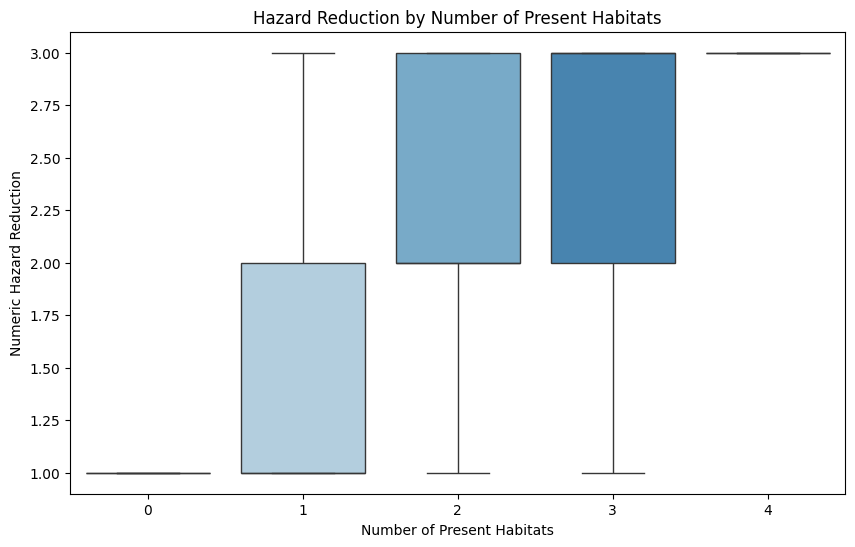

In [107]:
merged['num_habitats_present'] = merged[habitats].sum(axis=1)


correlation_num_habitats_reduction = merged['num_habitats_present'].corr(merged['Hazard_Reduction_by_Habitats_Numeric'])

print(f"Correlation between Number of Present Habitats and Hazard Reduction: {correlation_num_habitats_reduction:.2f}")


plt.figure(figsize=(10, 6))
sns.boxplot(x='num_habitats_present', y='Hazard_Reduction_by_Habitats_Numeric', data=merged, palette='Blues')
plt.title('Hazard Reduction by Number of Present Habitats')
plt.xlabel('Number of Present Habitats')
plt.ylabel('Numeric Hazard Reduction')
plt.show()

Correlation Matrix of Hazard Variables:


,Geomorphology_Hazard,Elevation_Hazard,Sea_Level_Rise_Hazard,Wave_Hazard,storm_surge_hazard,Erosion_Rate_Hazard
Geomorphology_Hazard,1.000000,0.163259,0.126396,-0.048379,0.239495,0.109790
Elevation_Hazard,0.163259,1.000000,0.463553,0.095471,0.498497,0.173882
Sea_Level_Rise_Hazard,0.126396,0.463553,1.000000,0.101936,0.196181,0.106533
Wave_Hazard,-0.048379,0.095471,0.101936,1.000000,0.080208,0.142716
storm_surge_hazard,0.239495,0.498497,0.196181,0.080208,1.000000,0.101034
Erosion_Rate_Hazard,0.109790,0.173882,0.106533,0.142716,0.101034,1.000000


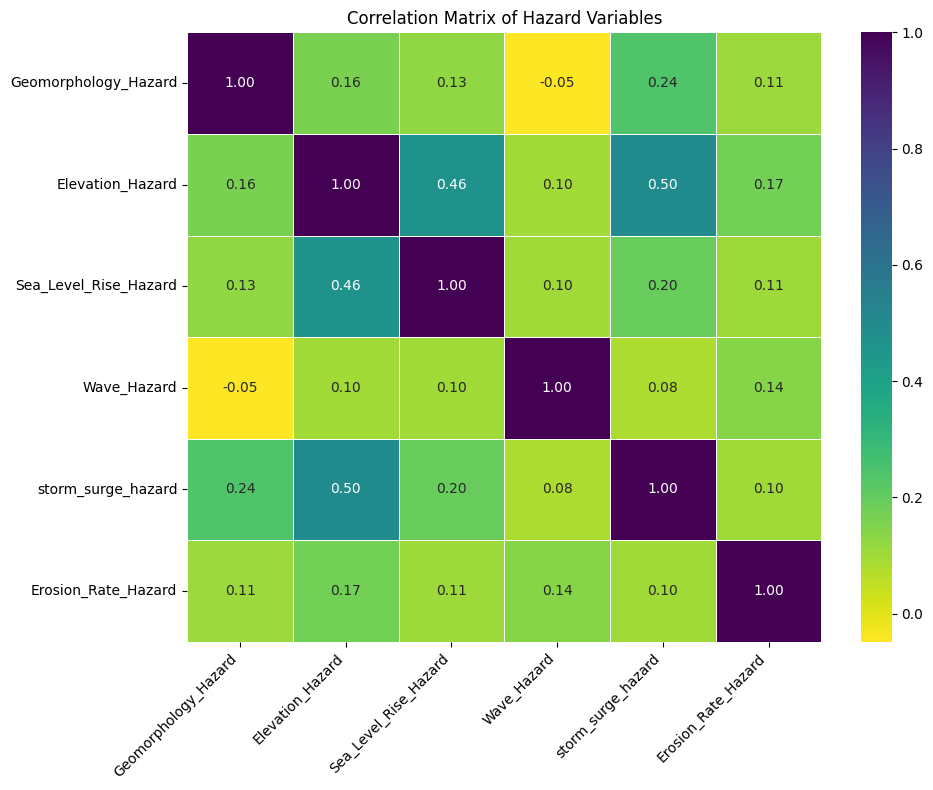

In [108]:
hazard_numeric_df = pd.DataFrame()
for col in hazard_cols:
    if col in merged.columns:

        hazard_numeric_df[col] = pd.Categorical(merged[col], categories=hazard_order, ordered=True).codes


correlation_matrix_hazards = hazard_numeric_df.corr()


print("Correlation Matrix of Hazard Variables:")
display(correlation_matrix_hazards)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_hazards, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Hazard Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Descriptive Statistics for PercentRemaining2100:


,PercentRemaining2100
count,11280.000000
mean,38.254013
std,33.404556
min,-0.000011
25%,3.112141
50%,34.024355
75%,67.316346
max,100.000000


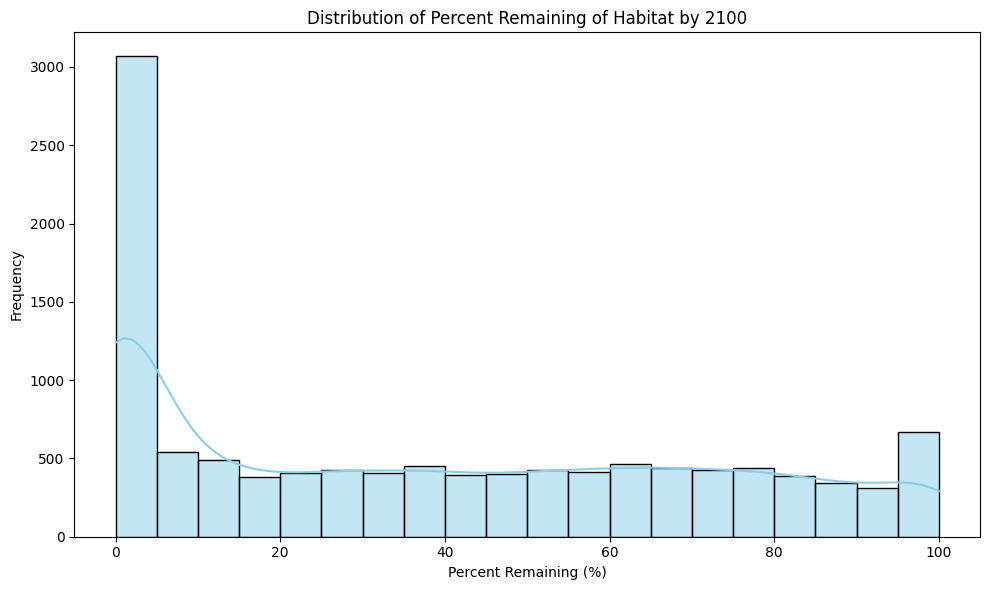

In [109]:
#used built-in Gemini
if 'PercentRemaining2100' in merged.columns:
    print("Descriptive Statistics for PercentRemaining2100:")
    display(merged['PercentRemaining2100'].describe())


    plt.figure(figsize=(10, 6))
    sns.histplot(merged['PercentRemaining2100'].dropna(), bins=20, kde=True, color='skyblue')
    plt.title('Distribution of Percent Remaining of Habitat by 2100')
    plt.xlabel('Percent Remaining (%)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'PercentRemaining2100' not found in the DataFrame.")